# WIND POWER FORECASTING - PRACTICAL CASE




## EXERCISE 1:

In the csv attached you can find data about a forecasted wind park with an installed
capacity of 10 MW. On the file you can find the following columns:
- Time: time of the measurement/prediction, in UTC.
- PowerMeas: measurement of the power output of the wind farm for the specific hour, in MW.
- WindSpeedMeas: measurement of the wind speed for the specific hour, in m/s.
- PowerPred6HA: power forecast for a 6 hour ahead horizon generated by a forecasting
engine, in MW.

Regarding that data, answer the following questions:

### Question a)

##### Read the csv using your favorite programming language and make an initial inspection of the dataset. Is there anything remarkable at first sight?

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from yfinance.scrapers import holders

# Read csv
data=pd.read_csv("forecast_data.csv")

# Understand the type of data
print(f"Check type of data and shape of data")
print(data.dtypes)
print(data.shape)

# Now we get the number of NaN in each column. We should clean this afterwards for question b)
print("Number of NaN:")
print(data.isna().sum())

Check type of data and shape of data
TimeMeas             str
PowerMeas        float64
WindSpeedMeas    float64
PowerPred6HA     float64
dtype: object
(2207, 4)
Number of NaN:
TimeMeas           0
PowerMeas        107
WindSpeedMeas    182
PowerPred6HA       6
dtype: int64


Let´s get a first impression by plotting the time series all together

Individual representation of the 3 variables: PowerMeas, WindSpeedMeas, and PowerPred6HA


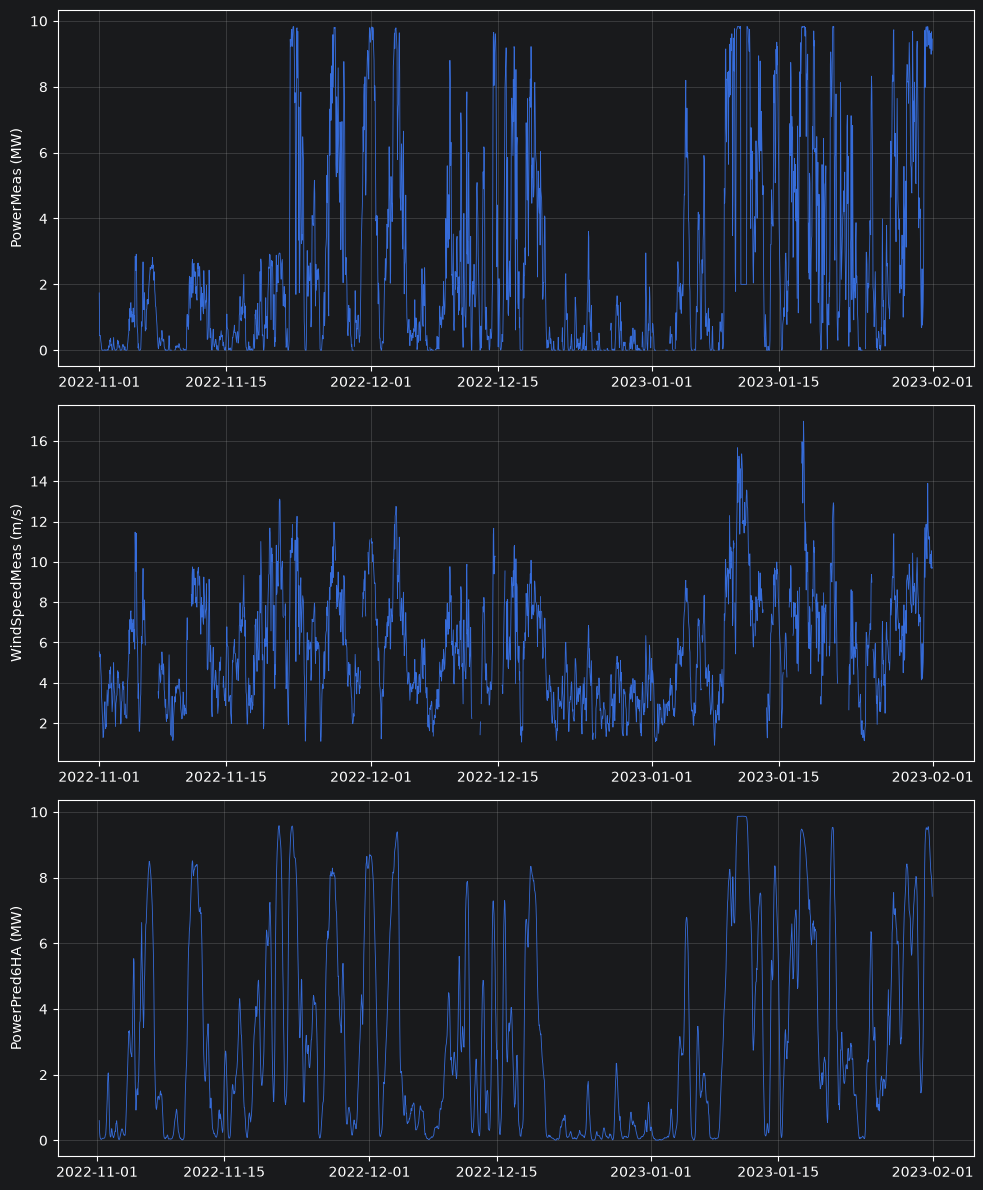

In [2]:
# Get a first sight by plotting the time series all together
import os

os.makedirs("Figures", exist_ok=True)

print("Individual representation of the 3 variables: PowerMeas, WindSpeedMeas, and PowerPred6HA")
data["TimeMeas"] = pd.to_datetime(data["TimeMeas"])

titles = ["PowerMeas (MW)", "WindSpeedMeas (m/s)", "PowerPred6HA (MW)"]
columns = ["PowerMeas", "WindSpeedMeas", "PowerPred6HA"]

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

for ax, col, title in zip(axes, columns, titles):
    x = data["TimeMeas"]
    ax.plot(x, data[col],linewidth=0.6)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Figures/individual_time_series.png", dpi=200)
plt.show()


Now let´s combine them in 1 same plot

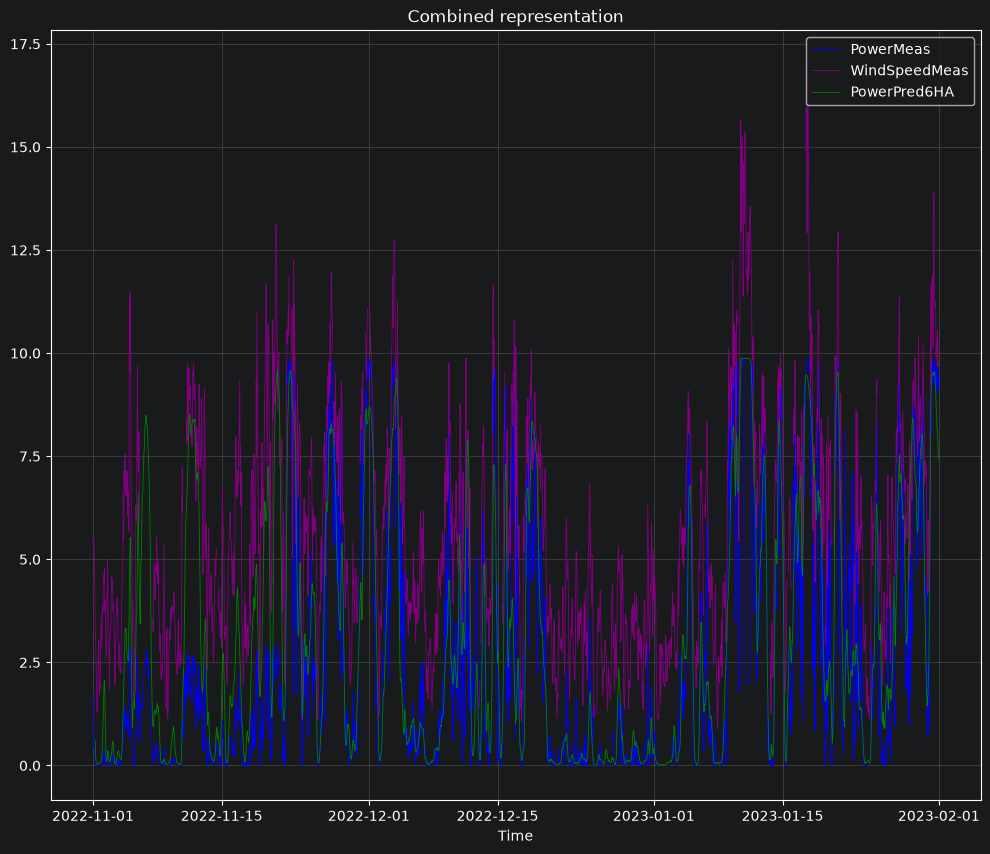

In [3]:
# Combined representation of the 3 variables
os.makedirs("Figures", exist_ok=True)

colors=["b","purple","g"]
fig=plt.figure(figsize=(12, 10),)
for colors,col in zip(colors,columns):
    x=data["TimeMeas"]
    plt.plot(x,data[col],linewidth=0.6,color=colors)
    plt.grid(True, alpha=0.3)
    plt.title("Combined representation")
    plt.legend(columns,loc="upper right")
    plt.xlabel("Time")
plt.savefig("Figures/combined_time_series.png", dpi=200)
plt.show()


It can be observed that there is some difference between the measured and the predicted, so let´s calculate the residual simply to confirm this first impression

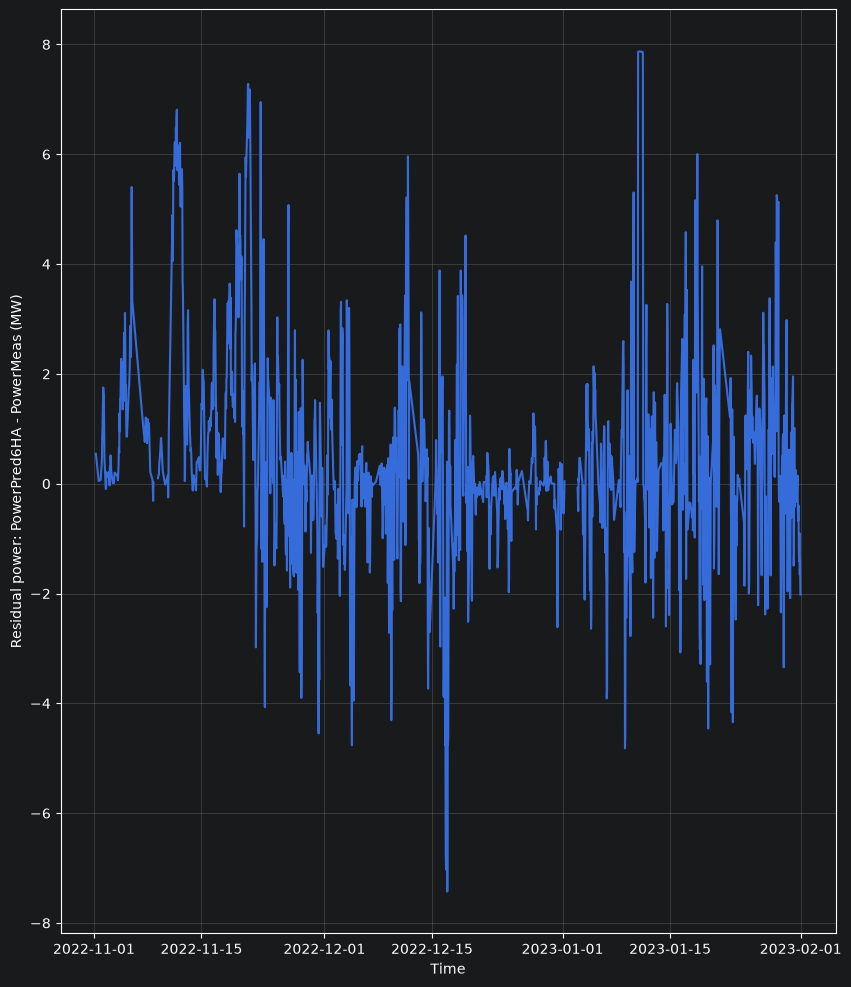

In [4]:
# Residual with wind speed over cut in
cut_in=round(np.min(data["WindSpeedMeas"][data["PowerMeas"]>0.2]))
data_copy=data.copy()
data_copy=data_copy[data_copy["WindSpeedMeas"]>=cut_in]
residual_power=data_copy["PowerPred6HA"] - data_copy["PowerMeas"]

# Represent figure
fig=plt.figure(figsize=(10,12))
plt.plot(data_copy["TimeMeas"],residual_power)
plt.grid(True, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Residual power: PowerPred6HA - PowerMeas (MW)")
plt.show()


### Conclusion (Question a)

- The dataset covers **2022-11-01 to 2023-01-31** at **hourly** resolution (2207 rows), with `TimeMeas`, `PowerMeas`, `WindSpeedMeas`, and `PowerPred6HA`. No timestamps are missing or duplicated.
- There are **missing values** in the numeric columns (`PowerMeas`: 107, `WindSpeedMeas`: 182, `PowerPred6HA`: 6) that should be handled before any further modelling.
- No `PowerMeas` or `PowerPred6HA` value exceeds the farm's 10 MW rated capacity, which is a good sanity check on the data.
- Visually, `PowerMeas` and `PowerPred6HA` broadly follow `WindSpeedMeas`, as expected, but there are clear periods where they diverge.
- Filtering to timestamps with wind speed above the estimated cut-in and plotting the residual (`PowerPred6HA - PowerMeas`) confirms this: there are sustained periods of significant **positive residual / overprediction** (measured power well below forecast) despite sufficient wind, suggesting curtailment, downtime, or turbine faults rather than pure forecast noise.
- A deeper look at this (e.g. relating the residual to the power curve) is left for **Question b)**, where the power curve is built explicitly.

### Question b)

##### Make a scatter plot of the power curve (that is power production measurement vs wind speed measurement) of the wind farm using a subset of the data covering from 2022-11-23 to 2023-01-09 and describe what you observe.

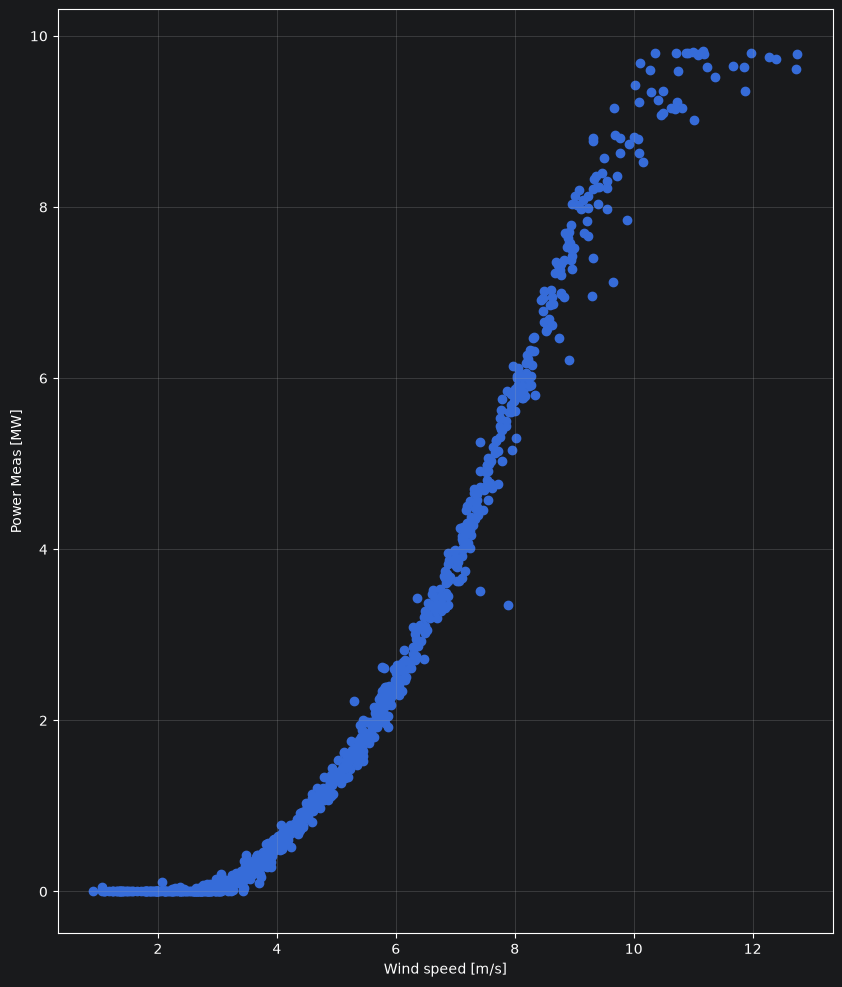

In [5]:
# 1. We clean the data
data_clean=data.copy()
data_clean=data_clean.dropna()

# 2. Filter by date
datestart=pd.to_datetime("2022-11-23")
dateend=pd.to_datetime("2023-01-09")
data_clean["TimeMeas"]=pd.to_datetime(data_clean["TimeMeas"]) # Convert to datetime so that we can compare
datab=data_clean[(data_clean["TimeMeas"]>=datestart) & (data_clean["TimeMeas"]<=dateend)]

# 3. Plot: Power production measurement vs wind speed measurement
fig=plt.figure(figsize=(10,12))
plt.scatter(datab["WindSpeedMeas"],datab["PowerMeas"])
plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power Meas [MW]")
plt.grid(True, alpha=0.3)
plt.show()


Observations:

First of all, for a detailed analysis to understand the scatter power curve, information should be given about how the measurement power curve was obtained and whether any filtering has been applied. Power measurements typically come from either SCADA data or from internal systems specific per manufacturer such as the TPPI system by SGRE. Once the data is received and accepted after a UAT (User Acceptance Test) it should be properly filtered according to the use that is going to be made of this data.

If, for instance, this use is a Power Curve Verification Campaign, the current scatter power curve would not be accepted. However, if not many filters have been applied to the variable PowerMeas and this is a "raw" representation of a real operational behavior, then the scatter power curve shows a very decent behavior.

This information is unknown in the current analysis, so I will briefly list some general observations on the scatter curve
- There is a reduced scatter which is an indication of a good behavior.
- Slightly more scatter is found close to "region 3" or rated power area. This is relatively common and can be due to different reasons such as:
    - Adjustments of the pitch angle that can be affected by a high turbulence intensity (stronger wakes coming from a            specific wind direction)
    - Data not filtered by free sector (the sector where there are no disturbances by any near wind turbine or any other obstacle)
    - Atmospheric variations that could affect the shear/veer of the wind turbine
    - Possible seasonality effect due to variations of air density / wind directions (although the measurement period is a short one so I don't expect this reason to have a high influence)
    - Yaw misalignment: the wind turbine stops facing perpendicular to the incoming wind speed. This is a continuous oscillating variable that reduces the aerodynamic efficiency so it can affect the power curve. This reason could potentially be confirmed/rejected in a more detailed analysis which I guess is out of the purpose of this exercise
    - Others: icing, temperature curtailment, grid curtailment, noise at high wind speed, errors in possible "boost" systems that modern wind turbines count with (unlikely reason as the rated power of 10 MW is never exceeded)
- Few data points behave in an unexpected way following same reasons as above
- For a further analysis it would help to know the source of the wind speed measurement (nacelle based lidar, SCADA anemometer, floating lidar, mesoscale, ...). Also, in case either PowerMeas or WindSpeedMeas is an instantaneous measurement instead of an average, this could lead to horizontal scatter


### Question c)

##### Repeat the same plot but using the power prediction instead of the power measurement. What is the main difference with the plot in 1.2 and how can you explain it?

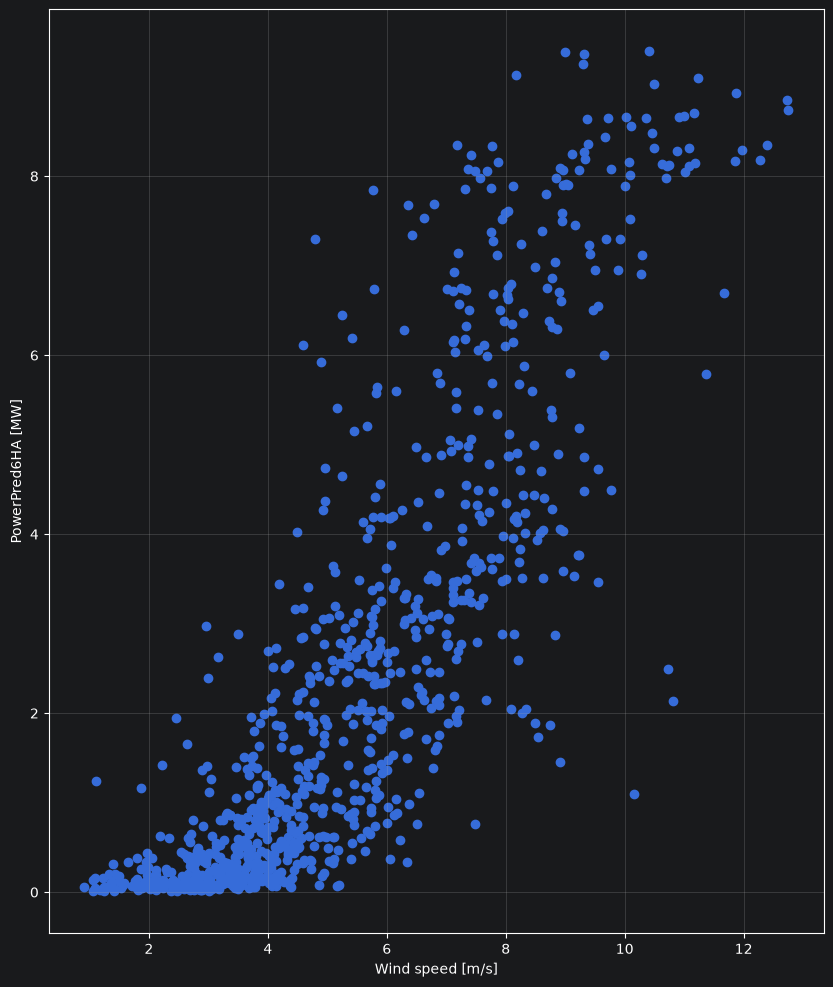

In [6]:
# Plot: Power prediction vs wind speed measurement
fig=plt.figure(figsize=(10,12))
plt.scatter(datab["WindSpeedMeas"],datab["PowerPred6HA"])
plt.xlabel("Wind speed [m/s]")
plt.ylabel("PowerPred6HA [MW]")
plt.grid(True, alpha=0.3)
plt.show()

Results for this scatter power curve are totally different than for the PowerMeas power curve. Now it can be seen a wide scatter both horizontal and vertically. This range cannot be due to operational/performance reasons as explained in 1b) but it represents the scatter due to the forecasting model.

What it is represented in 1c is the wind speed measurement at time t and the forecasted power, which uses as an input the predicted wind speed at time t using an horizon of 6h (so at t-6, the wind speed at t was predicted). It is expected some deviation between the predicted and the real wind speed and it must be highlighted that small wind speed deviations in region 2 of the power curve (for this example, something between 4-9 m/s) can lead to large changes in power, as in this area the power curve is very steep and sensitive to wind speed changes.

A similar reasoning can be used to both cut in and rated area. A 1-2m/s wind speed deviation can either delay the power production extending the cut in, or delay/anticipate the rated power.

To sum up, the main difference between 1b) and 1c) is that 1c uses the power based on the forecasted wind speed, not the actual one. However, as it is compared to the actual one, the small deviations in the wind speed forecasting model lead to high scatter on the power curve.

In order to get more information about the forecasting model we could plot the PowerMeas scatter power curve together with the residual (defined as `PowerPred6HA - PowerMeas`, consistent with the Bias convention used in 1d), so we can see where the predicted power differs more from actual power. See the figure below. Observations show that a higher positive residual (overprediction) is found for smaller wind speeds, and higher negative residuals (underprediction) for larger wind speeds. This means that the forecasting model tends to overpredict at low-to-mid wind speeds (cut-in / region 2) and underpredict at high wind speeds, closer to the rated power region.

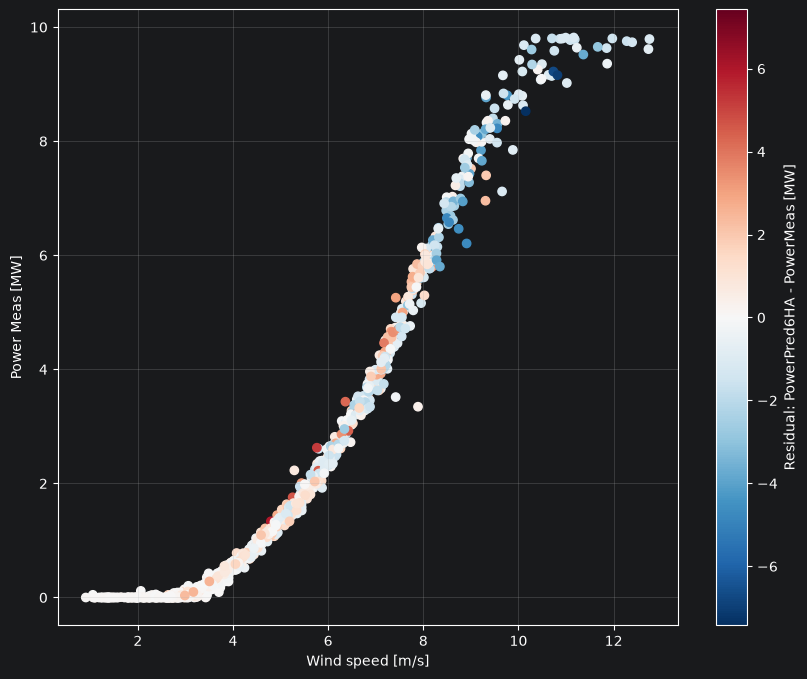

In [7]:
# Scatter PowerMeas power curve with residual as colorbar
residual_power_c=datab["PowerPred6HA"]-datab["PowerMeas"]

# 3. Plot: Power production measurement vs wind speed measurement, colored by residual
fig=plt.figure(figsize=(10,8))
vmax=residual_power_c.abs().max()
sc=plt.scatter(datab["WindSpeedMeas"],datab["PowerMeas"],c=residual_power_c,cmap="RdBu_r",vmin=-vmax,vmax=vmax)
cbar=plt.colorbar(sc)
cbar.set_label("Residual: PowerPred6HA - PowerMeas [MW]")
plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power Meas [MW]")
plt.grid(True, alpha=0.3)
plt.show()


### Question d)

##### Compute and plot the average normalized Bias for each of the days of the period. Do you find anything remarkable?

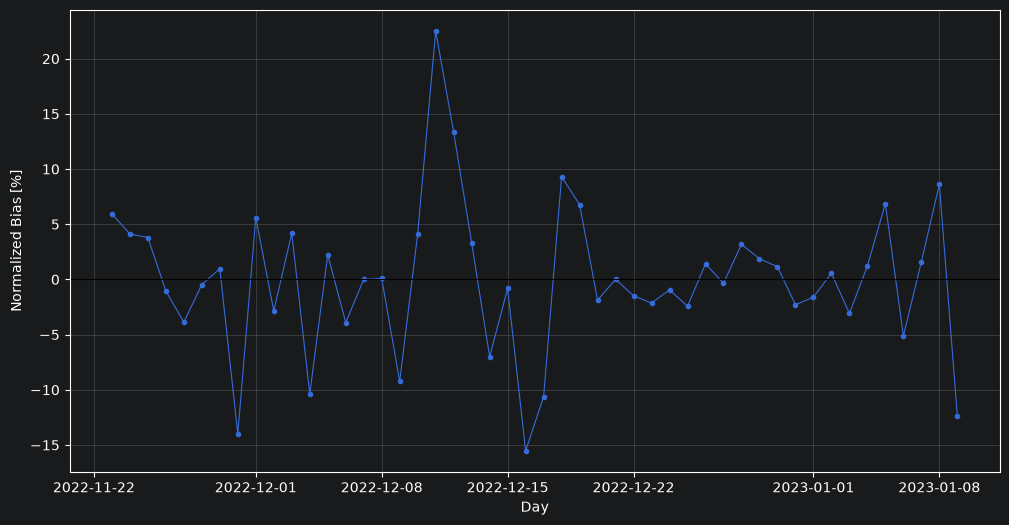

[np.float64(66.66666666666666), np.float64(18.75), np.float64(10.416666666666668), np.float64(4.166666666666666)]
Mean bias is: -0.015292666959518364


In [8]:
# Average normalized Bias per day (Bias = PowerPred6HA - PowerMeas, normalized by installed capacity)
rated_capacity = 10  # MW

datab["Bias"] = datab["PowerPred6HA"] - datab["PowerMeas"]
daily_bias = datab.set_index("TimeMeas")["Bias"].resample("D").mean() / rated_capacity * 100

fig = plt.figure(figsize=(12, 6))
plt.plot(daily_bias.index, daily_bias.values, marker="o", markersize=3, linewidth=0.8)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Day")
plt.ylabel("Normalized Bias [%]")
plt.grid(True, alpha=0.3)
plt.show()

# Get some basic stats
rangesbias=np.array([0,5,10,15,25])
countbias=[]
for i in range(len(rangesbias)-1):
    countbias.append(((daily_bias.abs() > rangesbias[i]) & (daily_bias.abs() <= rangesbias[i+1])).sum()/len(daily_bias)*100)
print(countbias)
print(f"Mean bias is: {daily_bias.mean()}")



The normalized bias does not show a specific pattern which could mean that the forecasting model is biased. Computing a fast statistical analysis it can be observed that around 2/3 of datapoints fall under 5%. The range of 5-10% bias is around 19% of the time, 10-15% around 10% and finally just 4% are over 15% bias which could simply be considered as statistical error. In addition, the mean bias is only 0.015%.

The only period that could be slightly concerning is the period between the 2022-12-09 and 2022-12-20, where there is a higher proportion of peaks. Question f) already highlights to analyze this area suggesting a power curve to study what happens, so this area will not be analyzed. Instead what it can be done is a general analysis to understand the behavior of the forecasting model.

It was already seen in the previous section that the model overpredicts for low wind speeds and underpredicts for high wind speeds.

Another analyze to get more information could be to check if the model is able to adapt to fast changes in wind speed, which is a common handicap for forecasting models. For this purpose, we can compare the change in power during the horizon of the model (6h).

The forecasting model aims to predict the power with 6h in advance. To check the dependency to fast changes, we can do a linear reggresion comparing the "Real Change" = PowerMeas[t] - PowerMeas[t-6] and the "Predicted Change" = PowerPred6HA[t] -PowerPred6HA[t-6].

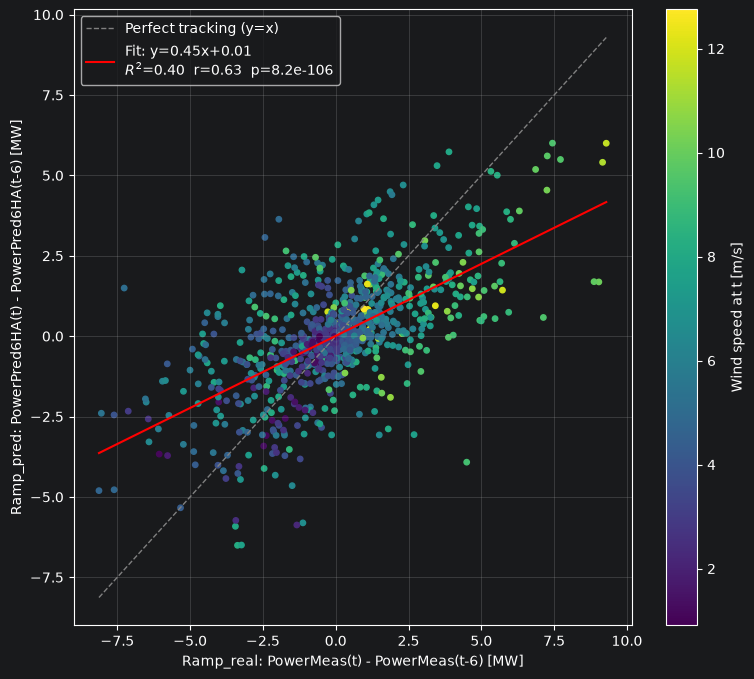

In [9]:
from scipy import stats

# Build a regular hourly grid so shift(6) is a true 6h time-based lag (not positional)
data_hourly = data.set_index("TimeMeas").asfreq("h")
data_hourly["Change_real"] = data_hourly["PowerMeas"] - data_hourly["PowerMeas"].shift(6)
data_hourly["Change_pred"] = data_hourly["PowerPred6HA"] - data_hourly["PowerPred6HA"].shift(6)

sub = data_hourly.loc["2022-11-23":"2023-01-09"].dropna(subset=["Change_real", "Change_pred", "WindSpeedMeas"])

# Linear regression: how well does the predicted ramp track the real Change?
res = stats.linregress(sub["Change_real"], sub["Change_pred"])

fig = plt.figure(figsize=(9, 8))
sc = plt.scatter(sub["Change_real"], sub["Change_pred"], c=sub["WindSpeedMeas"], cmap="viridis", s=15)
cbar = plt.colorbar(sc)
cbar.set_label("Wind speed at t [m/s]")

x_line = np.array([sub["Change_real"].min(), sub["Change_real"].max()])
plt.plot(x_line, x_line, color="grey", linestyle="--", linewidth=1, label="Perfect linear fit (y=1x+0)")
plt.plot(
    x_line, res.slope * x_line + res.intercept, color="red", linewidth=1.5,
    label=f"Fit: y={res.slope:.2f}x+{res.intercept:.2f}\n$R^2$={res.rvalue**2:.2f}  r={res.rvalue:.2f}  p={res.pvalue:.1e}"
)

plt.xlabel("Change_real: PowerMeas(t) - PowerMeas(t-6) [MW]")
plt.ylabel("Change_pred: PowerPred6HA(t) - PowerPred6HA(t-6) [MW]")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.show()


The linear regression above shows that the larger the change in power is for a 6h horizon (either positive or negative change), the more error there is in the forecasting model, which means this model struggles to adapt to fast changes in power or wind speed.

The function used provides some statistical parameters. Let´s explain them briefly:

- Fit (y = 0.45x -0.01): for every increase of x, y increases 0.45. A perfect fit would be y=x
- R^2 (R-squared) = 0.40: it expresses what percentage of the variability in y can be explained by x in between 0 and 1. So 0.40 means there is a high scatter that cannot be explained with this analysis
- r (Pearson correlation coefficient, r=0.63): it is r^2
- p (p-value =8.2e-10^6): it shows the probability of observing the current "Fit" if there were no correlation between the 2 variables. This p-value is very small, so there is clear correlation between PowerMeas and PowerPred6HA

Without going to further details and in combination with the time series of bias, to answer question 1d) we can conclude that:

- The mean bias is very small, which indicates that in average the model is accurate
- There are some high peaks in the time series, which indicate the model cannot always make a good prediction
- By studying the behavior of the model to changes in Power, the model shows a high correlation between PowerMeas and PowerPred6HA, but it also struggles to adapt to fast changes in power


### Question e)

##### Compute the MAE (Mean Absolute Error) and the squared error for each of the forecasts during the whole period of the dataset. Plot the time series of the MAE and the squared error during the period and make a cumulative sum plot for each of them. What do you observe?

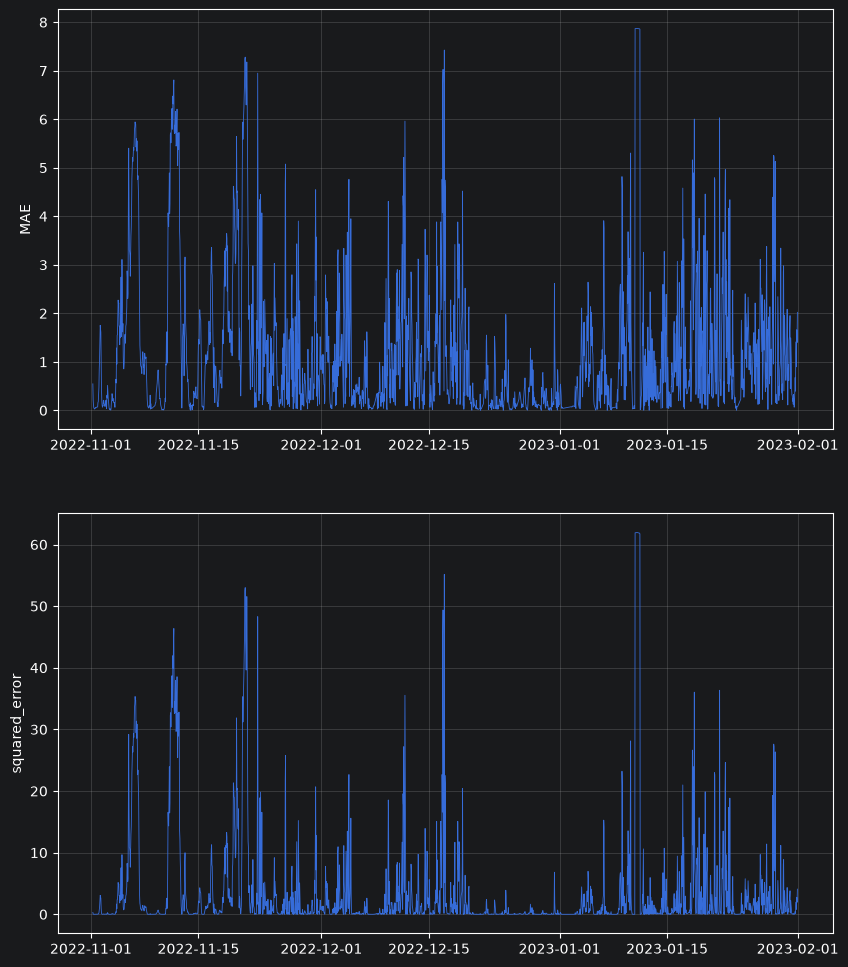

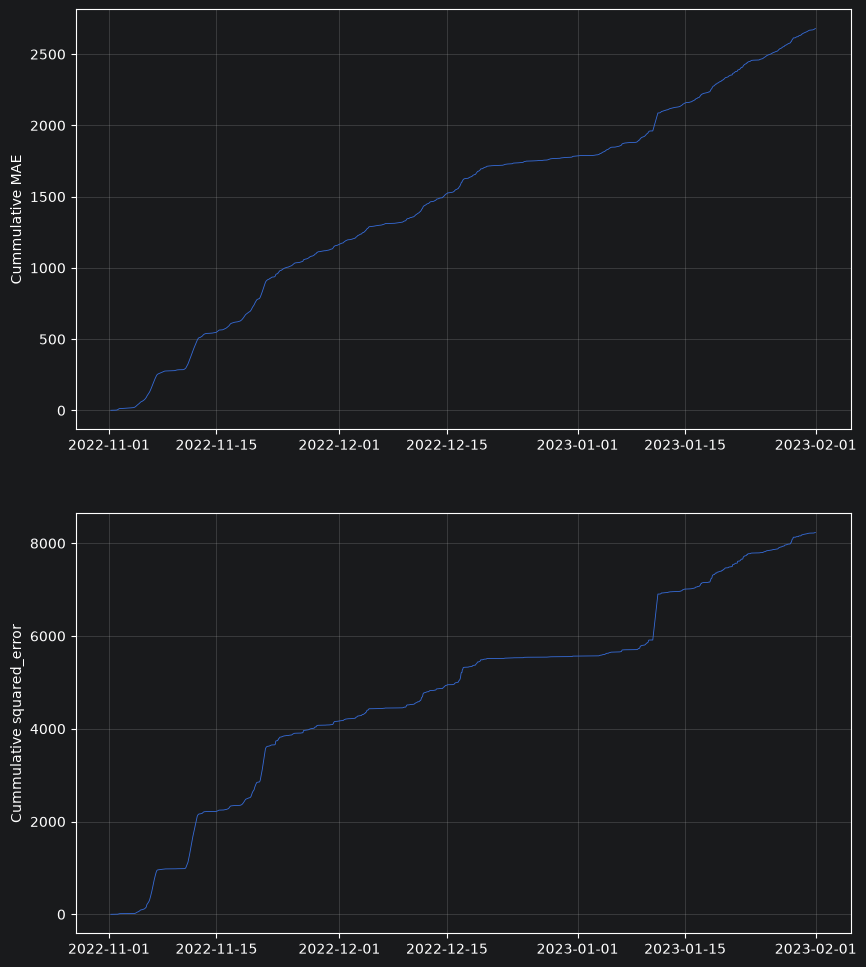

In [15]:
# 1. Calculate MAE
datae=data.dropna(subset=["PowerMeas","PowerPred6HA"])
MAE=abs(datae["PowerMeas"]-datae["PowerPred6HA"])

# 2. Calculate squared error
squared_error=MAE*MAE

# 3. Plot time series of MAE and r-square
fig, axes = plt.subplots(2, 1, figsize=(8, 12), sharex=False)
columns=[MAE,squared_error]
titles=["MAE [MW]","squared_error [MW^2]"]
for ax, col, title in zip(axes, columns, titles):
    x = datae["TimeMeas"]
    ax.plot(x, col,linewidth=0.6)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
plt.show()

# 4. Plot cumulative MAE and cumulative r-square
fig, axes = plt.subplots(2, 1, figsize=(8, 12), sharex=False)
titles=["Cumulative MAE [MW]","Cumulative squared_error [MW^2]"]
for ax, col, title in zip(axes, columns, titles):
    x = datae["TimeMeas"]
    ax.plot(x, col.cumsum(),linewidth=0.6)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
plt.show()


Observations:

- The main observation is that peaks on the bias (PowerMeas - PowerPred6HA) are much more pronounced on the Squared error than on the MAE. This is clear to observe on the cumulative plot

### Question f)

##### Can you try to explain what happens between 2023-01-10 and 2023-01-11? You can make a power curve plot of the period 2022-11-23 to 2023-01-31 to help you understand it.

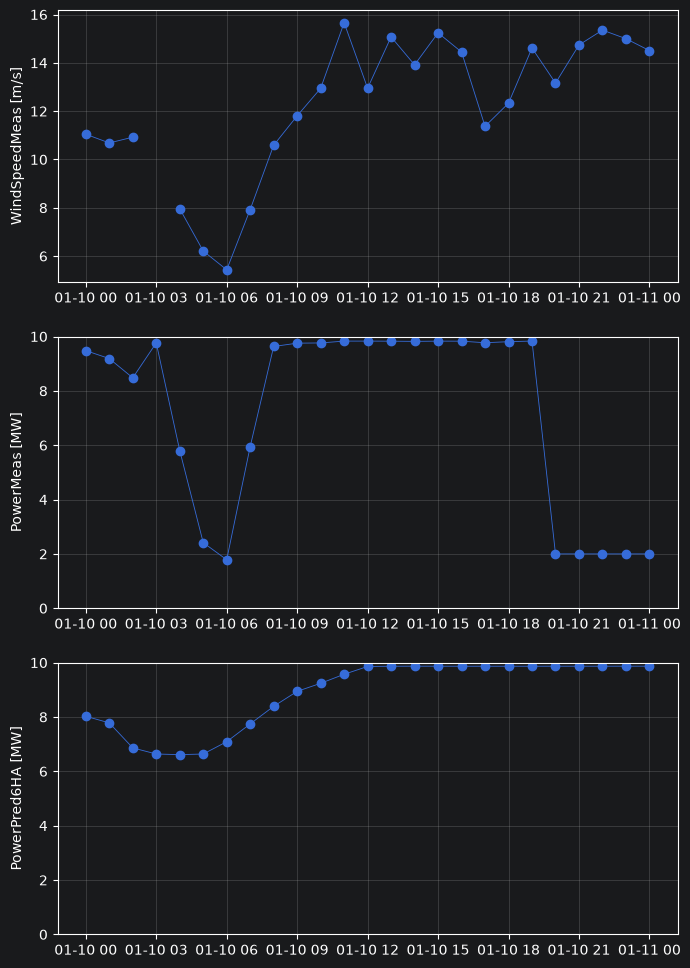

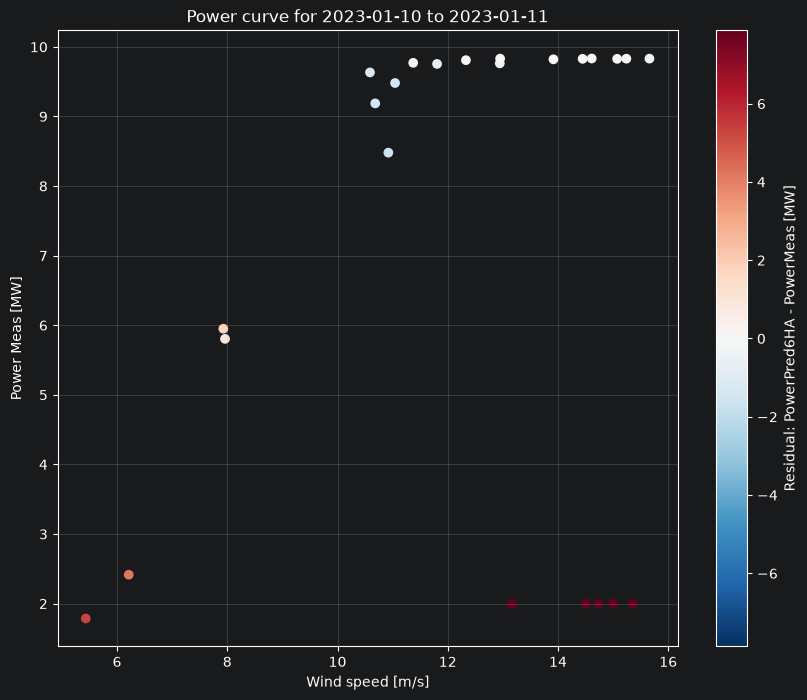

In [28]:
# 1. Get the data
dataf=data.copy()
dataf["TimeMeas"]=pd.to_datetime(dataf["TimeMeas"])
dataf=dataf[(dataf["TimeMeas"]>="2023-01-10") & (dataf["TimeMeas"]<="2023-01-11")]

# 2. Plot the time series of wind speed and PowerMeas
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=False)
columns=[dataf["WindSpeedMeas"],dataf["PowerMeas"],dataf["PowerPred6HA"]]
titles=["WindSpeedMeas [m/s]","PowerMeas [MW]","PowerPred6HA [MW]"]
for ax, col, title in zip(axes, columns, titles):
    x = dataf["TimeMeas"]
    ax.plot(x, col,'-o',linewidth=0.6)
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
axes[1].set_ylim(0, 10)
axes[2].set_ylim(0, 10)
plt.show()

# 3. Make power curve plot: for this period
residual_power_f=dataf["PowerPred6HA"]-dataf["PowerMeas"]
fig=plt.figure(figsize=(10,8))
vmax=residual_power_f.abs().max()
sc=plt.scatter(dataf["WindSpeedMeas"],dataf["PowerMeas"],c=residual_power_f,cmap="RdBu_r",vmin=-vmax,vmax=vmax)
cbar=plt.colorbar(sc)
cbar.set_label("Residual: PowerPred6HA - PowerMeas [MW]")
plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power Meas [MW]")
plt.title("Power curve for 2023-01-10 to 2023-01-11")
plt.grid(True, alpha=0.3)
plt.show()




The power curve plot that, in my opinion, it helps to understand what happens in the period from 2023-01-10 to 2023-01-11 is the power curve from 2023-01-10 to 2023-01-11, instead of 2022-11-23 to 2023-01-31. This power curve offers a good overview to understand what is happening with the forecasting model. Let´s divide this plot in several area for its explanation.

*Area 1*: wind speed above 10 m/s and power around rated power (10 MW)

The rated wind speed is around 10 m/s. In this area 1 we can observe how the residual/bias is very low, meaning that the model was able to make an accurate forecast. Looking at the time series it corresponds to the period between 12h and 19h.

*Area 2*: wind speed above 10 m/s and power around 2 MW

By checking the time series it corresponds to the period between 20h and 24h. The PowerMeas is suddenly curtailed from rated power to 2MW. The forecasting model fails to capture this sudden change and gets stuck at rated power. The residual is very high meaning that the model is overpredicting. We could previously see that this used to happen for low wind speeds, however in this case it is happening for very high wind speeds. The reason is that this particular mismatch is simply because of the capacity to capture large changes, which is aligned with the observations from the linear regression from section d).

If for instance, we take t=22h, then t-6 = 16h. The ramp_real here would be a high negative number (2-10=-8 MW), which corresponds to the left side of the linear regression, in which the ramp_pred shows an overprediction.

*Area 3*: wind speed around 8 m/s and power around 6 MW

This area corresponds to the hour after the sudden drop in wind speed (h=4) and the hour after the sudden increase of power (h=7). In both cases, the forecasting model detects that there is a change but reacts late, getting a smother transition.

*Area 4*: wind speed around 6 m/s and power around 2 MW

This corresponds to hours 9 and 10, and the same smooth transition takes place as in Area 3, as the model fails to capture the sudden drop and then peak of power.

To sum up, this 1 day interval confirms some of the previous observations: the model fails to capture sudden changes of power, and particularly, the model overpredicts whenever the sudden change is negative.

If now, as asked in the exercise, the power curve for the period 2022-11-23 to 2023-01-31 is analyzed:



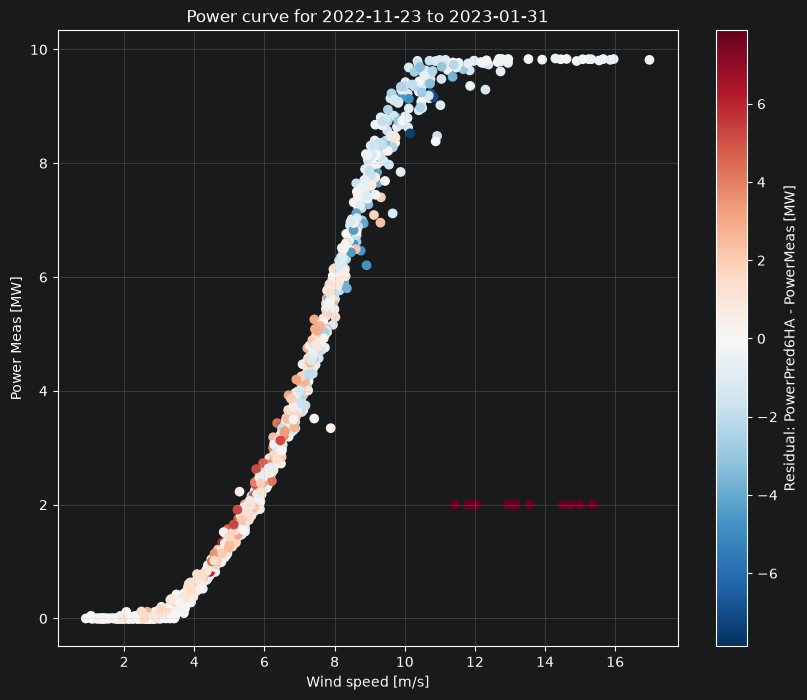

In [26]:
# Make power curve plot: for the period 2022-11-23 to 2023-01-31
dataf2=data.copy()
dataf2["TimeMeas"]=pd.to_datetime(dataf2["TimeMeas"])
dataf2=dataf2[(dataf2["TimeMeas"]>="2022-11-23") & (dataf2["TimeMeas"]<="2023-01-31")]
residual_power_f2=dataf2["PowerPred6HA"]-dataf2["PowerMeas"]
fig=plt.figure(figsize=(10,8))
vmax=residual_power_f2.abs().max()
sc=plt.scatter(dataf2["WindSpeedMeas"],dataf2["PowerMeas"],c=residual_power_f2,cmap="RdBu_r",vmin=-vmax,vmax=vmax)
cbar=plt.colorbar(sc)
cbar.set_label("Residual: PowerPred6HA - PowerMeas [MW]")
plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power Meas [MW]")
plt.title("Power curve for 2022-11-23 to 2023-01-31")
plt.grid(True, alpha=0.3)
plt.show()

 Looking at the power curve for the period of 2022-11-23 to 2023-01-31, the event analyzed above is not an isolated case. There is a clear cluster of points fixed at exactly 2 MW for wind speeds between ~11.5 and 15.5 m/s, clearly detached from the main power curve — these are also the points with the largest (most positive) residual in the entire dataset. This confirms that the wind turbine is curtailed to a fixed setpoint on more than one occasion during the period (or it is a continuation of the previous curtailment), and that the forecasting model consistently overpredicts every time this happens.

### Question g)

##### Make a power curve plot for the whole period of the dataset. Do you observe anything else besides what has already been pointed out?

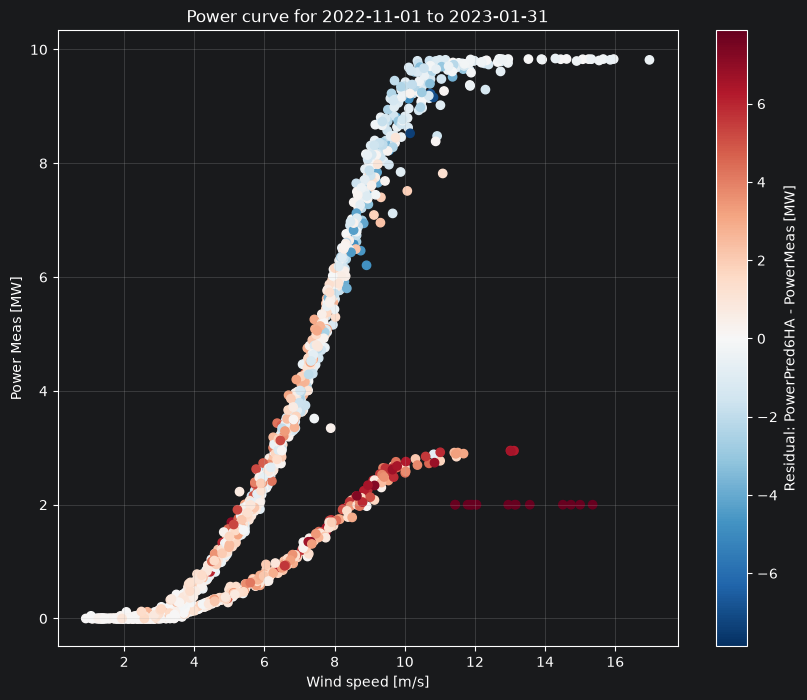

In [27]:
# Get the right data
datag=data.copy()
datag["TimeMeas"]=pd.to_datetime(datag["TimeMeas"])
datag=datag.dropna(subset=["TimeMeas","PowerPred6HA","PowerMeas","WindSpeedMeas"])
residual_power_g=datag["PowerPred6HA"]-datag["PowerMeas"]

# Plot the power curve
fig=plt.figure(figsize=(10,8))
vmax=residual_power_g.abs().max()
sc=plt.scatter(datag["WindSpeedMeas"],datag["PowerMeas"],c=residual_power_g,cmap="RdBu_r",vmin=-vmax,vmax=vmax)
cbar=plt.colorbar(sc)
cbar.set_label("Residual: PowerPred6HA - PowerMeas [MW]")
plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power Meas [MW]")
plt.title("Power curve for 2022-11-01 to 2023-01-31")
plt.grid(True, alpha=0.3)
plt.show()

This new power curve shows two sets of different values:

1. Similar behavior as commented in the previous section
2. New clear underperforming values, that must correspond to the period of 2022-11-01 to 2022-11-23. Let´s focus on this new set, that we can call, for internal understanding, as "underperformed power curve"

The "underperformed power curve" indicates that this data has not been filtered, and it could be explained by:

- Possible severe yaw misalignment: although the wind turbine owner should detect this in advance, without letting the wind turbine run for long with this issue-
- Predominant wind from an area with a lot of obstacles leading to very high turbulence intensity which could potentially activate some protective mechanisms of the wind turbine. Maybe for a period of time there was an obstacle that was later on removed.
- Grid curtailments in the wind farm for a prolonged period of time. This is one of the most likely reasons
- Temperature curtailments, although it does not match as we are in winter and this type of behaviour could more common for high temperatures than for cold temperatures
- Noise restrictions during a specific period of time



### Question h)

##### What do you think could happen with the power forecast if all the power measurements provided in this dataset would enter the training of WindFor? How would you suggest fixing any possible issue ccaused by it?

First of all, my understanding of WindFor is very limited. I have checked briefly what you show in your website and I have read a bit about general forecasting models and how they work. With this in mind, I will try to answer to the 2 questions:

*Question 1: What do you think could happen with the power forecast if all the power measurements provided in
this dataset would enter the training of WindFor?*

So I understand that this data has not been used to train WindFor. The data, after the analysis in question g), seems to have some unexpected measurements from the 1st of November to the 23rd of November. The power that is measured during this period cannot be explained by the wind speed, it must be due to other factors affecting the performance (factors mentioned in question g).

In case these factors are considered as anomalies, the data obtained during this period should not be used to train WindFor, otherwise WindFor will consider this contaminated data for periods in which these factors are taking place. The consequence would be systematic underprediction by WindFor, especially from 5 m/s (as before the influence of the underprediction is not remarkable)

However, in case these factors are not anomalies, but specific circumstances that are always/frequently repeated under specific known circumstances, then this data should be used, only in WindFor learns to use this data whenever those circumstances are happening again, e.g. imagine every November there is a grid curtailment that limits max production to 5MW, then WindFor should learn that for forecasting of November data, the max production will be capped to 5MW.

*Question 2: How would you suggest fixing any possible issue caused by it?*

The problem is to identify the source of the contaminated data. This is basically what I did at Ørsted when running a Power Curve Verification campaign. You need to have access to SCADA data or any other internal data system by the manufacturer, and you also need to be aware of specific conditions taking place in the wind farm (such as grid curtailments following the example). The IEC Standards also provide information of how to verify a power curve, by defining specific ranges of operation under which you can compared the measured power curve with the warranted power curve.

Once it is identified the reasons of the mismatch between warranted (expected behavior) and measured (real behavior), you should decide if the anomalies are included or not. If the anomalies are not desired (as they are not repetitive circumstances that happen in the wind farm), then you should filter all the data that is affected and then run WindFor with the clean data. In case the anomalies are desired, then you should teach WindFor to curtail under those specific anomalies.